# Install Libraries

In [1]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install cpi

Note: you may need to restart the kernel to use updated packages.


In [5]:
import cpi
cpi.update()

C:\Users\pepec\AppData\Local\Programs\Python\Python314\Lib\site-packages\cpi\download.py:175: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(io.StringIO(response.text), sep="\t")
C:\Users\pepec\AppData\Local\Programs\Python\Python314\Lib\site-packages\cpi\download.py:175: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(io.StringIO(response.text), sep="\t")
C:\Users\pepec\AppData\Local\Programs\Python\Python314\Lib\site-packages\cpi\download.py:175: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(io.StringIO(response.text), sep="\t")
C:\Users\pepec\AppData\Local\Programs\Python\Python314\Lib\site-packages\cpi\download.py:175: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(io.StringIO(response.text)

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Reading the CSV File 

In [7]:
url = "https://raw.githubusercontent.com/AlvaDave/MTA-Inflation-Project/refs/heads/main/MTA%20Raw%20Data.csv"
df = pd.read_csv(url)
df.head()

,Year,Fare,30 Day Unlimited,14 Day Unlimited,7 Day Unlimited,1 Day
0,1904,$0.05,NaN,NaN,NaN,NaN
1,1905,$0.05,NaN,NaN,NaN,NaN
2,1906,$0.05,NaN,NaN,NaN,NaN
3,1907,$0.05,NaN,NaN,NaN,NaN
4,1908,$0.05,NaN,NaN,NaN,NaN


# Cleaning Data

In [8]:
# Renaming columns
df.columns = [
    "year",
    "base_fare",
    "30unlimited",
    "14unlimited",
    "7unlimited",
    "1unlimited"]
df.head()

,year,base_fare,30unlimited,14unlimited,7unlimited,1unlimited
0,1904,$0.05,NaN,NaN,NaN,NaN
1,1905,$0.05,NaN,NaN,NaN,NaN
2,1906,$0.05,NaN,NaN,NaN,NaN
3,1907,$0.05,NaN,NaN,NaN,NaN
4,1908,$0.05,NaN,NaN,NaN,NaN


In [9]:
# Remove Dollar Sign and Commas
df = df.replace(r"\$", "", regex=True)
df = df.replace(r",", "", regex=True)
df.head()

,year,base_fare,30unlimited,14unlimited,7unlimited,1unlimited
0,1904,0.05,NaN,NaN,NaN,NaN
1,1905,0.05,NaN,NaN,NaN,NaN
2,1906,0.05,NaN,NaN,NaN,NaN
3,1907,0.05,NaN,NaN,NaN,NaN
4,1908,0.05,NaN,NaN,NaN,NaN


In [10]:
# Remove Dollar Signs and extra commasfor Specific Columns
dollar_col  = ["base_fare",
    "30unlimited",
    "14unlimited",
    "7unlimited",
    "1unlimited"]

for col in dollar_col: # creates loop for each column
    df[col] = (
        df[col] # overwrites the df[col] with df[col...]
            .astype(str) # converts to text to replace 
            .str.replace("$","")
            .str.replace(",","")
            .astype(float) # not int because integers can"t have decimals. 
    )
df.head()    

,year,base_fare,30unlimited,14unlimited,7unlimited,1unlimited
0,1904,0.05,NaN,NaN,NaN,NaN
1,1905,0.05,NaN,NaN,NaN,NaN
2,1906,0.05,NaN,NaN,NaN,NaN
3,1907,0.05,NaN,NaN,NaN,NaN
4,1908,0.05,NaN,NaN,NaN,NaN


In [11]:
# Remove Extra Spaces 
df = df.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

In [12]:
# Year should remain as an integer and not string
df["year"] = (
    df["year"]
    .astype(str)      # make sure it"s text
    .str.strip()      # remove spaces at start/end
    .astype(int))      # convert to integer

In [13]:
# Dataset starts at 1905. CPI was first recorded in 1913
df = df[df["year"] >= 1913]   # CPI starts in 1913

In [14]:
# Year Index
df["year"] = pd.to_numeric(df["year"], errors="coerce") # Clean Year Column, numeric groups 
df = df.set_index("year")
df = df.sort_index() # sort over time
df.head()

,base_fare,30unlimited,14unlimited,7unlimited,1unlimited
year,,,,,
1913,0.05,NaN,NaN,NaN,NaN
1914,0.05,NaN,NaN,NaN,NaN
1915,0.05,NaN,NaN,NaN,NaN
1916,0.05,NaN,NaN,NaN,NaN
1917,0.05,NaN,NaN,NaN,NaN


In [15]:
# Drop 2026 because there will be no CPI for the year 2026
df.drop(labels=[2026],inplace=True)

In [16]:
 df.head(114)

,base_fare,30unlimited,14unlimited,7unlimited,1unlimited
year,,,,,
1913,0.05,NaN,NaN,NaN,NaN
1914,0.05,NaN,NaN,NaN,NaN
1915,0.05,NaN,NaN,NaN,NaN
1916,0.05,NaN,NaN,NaN,NaN
1917,0.05,NaN,NaN,NaN,NaN
...,...,...,...,...,...
2021,2.75,127.0,NaN,33.0,NaN
2022,2.75,127.0,NaN,33.0,NaN
2023,2.90,132.0,NaN,34.0,NaN


# Adjusting for Inflation WITHOUT FRED

In [17]:
#df.reset_index(inplace=True)
#df.head(200)

In [18]:
#df["cpi"] = df["year"].map(cpi.get)
#arget_cpi = cpi.get(2025)

#inflation_factor = target_cpi / df["cpi"]

#fare_cols = ["base_fare","30unlimited", "14unlimited","7unlimited","1unlimited"]

#df[[col + "_real_2023" for col in fare_cols]] = df[fare_cols].multiply(inflation_factor, axis=0)

In [19]:
#df.head(200)

# Adjusting for Inflation WITH FRED

In [20]:
pip install pandas-datareader

Note: you may need to restart the kernel to use updated packages.


In [21]:
import pandas_datareader.data as web
import datetime

In [22]:
# Desired time frame from FRED
start = datetime.datetime(1913,1,1)
end = datetime.datetime(2025,12,31)

cpi = web.DataReader("CPIAUCNS", "fred", start, end)
cpi.head()

,CPIAUCNS
DATE,
1913-01-01,9.8
1913-02-01,9.8
1913-03-01,9.8
1913-04-01,9.8
1913-05-01,9.7


In [23]:
# Find the mean in years
cpi_yearly = cpi.resample("YE").mean()
# Change it to index to simplify the year values
cpi_yearly.index = cpi_yearly.index.year

cpi_yearly.head()

,CPIAUCNS
DATE,
1913,9.883333
1914,10.016667
1915,10.108333
1916,10.883333
1917,12.825000


In [24]:
# Reset the index
cpi_yearly = cpi_yearly.reset_index()
# Rename columns
cpi_yearly.columns = ["year","cpi"]
cpi_yearly.head()

,year,cpi
0,1913,9.883333
1,1914,10.016667
2,1915,10.108333
3,1916,10.883333
4,1917,12.825000


In [25]:
# Merge cpi_yearly and df
df = df.merge(cpi_yearly, on="year", how="left")

In [26]:
df.head()

,year,base_fare,30unlimited,14unlimited,7unlimited,1unlimited,cpi
0,1913,0.05,NaN,NaN,NaN,NaN,9.883333
1,1914,0.05,NaN,NaN,NaN,NaN,10.016667
2,1915,0.05,NaN,NaN,NaN,NaN,10.108333
3,1916,0.05,NaN,NaN,NaN,NaN,10.883333
4,1917,0.05,NaN,NaN,NaN,NaN,12.825000


In [27]:
# 2025 will be the base year as it is the most recent year
target_cpi = cpi_yearly.loc[cpi_yearly["year"] == 2025, "cpi"].values[0]

fare_cols = ["base_fare","30unlimited","14unlimited","7unlimited","1unlimited"]

inflation_factor = target_cpi / df["cpi"]

df[[col+"_real_2025" for col in fare_cols]] = \
    df[fare_cols].multiply(inflation_factor, axis=0)

In [28]:
pip install aquarel

Note: you may need to restart the kernel to use updated packages.


In [29]:
from aquarel import load_theme

theme = load_theme("arctic_light")
theme.apply()

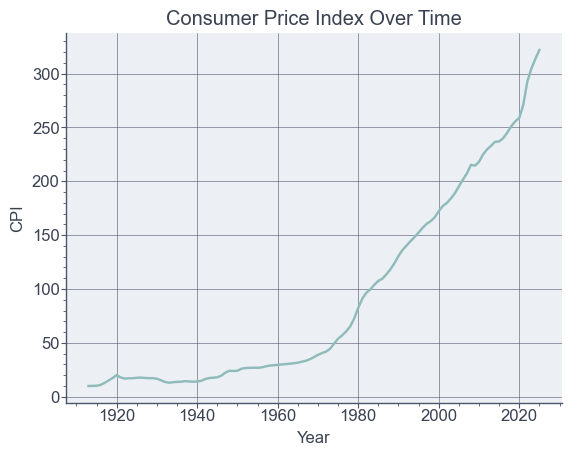

In [30]:
with load_theme("arctic_light"):
    plt.figure()

plt.plot(cpi_yearly["year"], cpi_yearly["cpi"])

plt.title("Consumer Price Index Over Time")

plt.xlabel("Year")
plt.ylabel("CPI")

plt.show()

In [31]:
df.head(200)

,year,base_fare,30unlimited,14unlimited,7unlimited,1unlimited,cpi,base_fare_real_2025,30unlimited_real_2025,14unlimited_real_2025,7unlimited_real_2025,1unlimited_real_2025
0,1913,0.05,NaN,NaN,NaN,NaN,9.883333,1.628717,NaN,NaN,NaN,NaN
1,1914,0.05,NaN,NaN,NaN,NaN,10.016667,1.607037,NaN,NaN,NaN,NaN
2,1915,0.05,NaN,NaN,NaN,NaN,10.108333,1.592463,NaN,NaN,NaN,NaN
3,1916,0.05,NaN,NaN,NaN,NaN,10.883333,1.479064,NaN,NaN,NaN,NaN
4,1917,0.05,NaN,NaN,NaN,NaN,12.825000,1.255138,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
108,2021,2.75,127.0,NaN,33.0,NaN,270.969750,3.267314,150.890500,NaN,39.207768,NaN
109,2022,2.75,127.0,NaN,33.0,NaN,292.654917,3.025212,139.709804,NaN,36.302547,NaN
110,2023,2.90,132.0,NaN,34.0,NaN,304.701583,3.064095,139.469167,NaN,35.923876,NaN
111,2024,2.90,132.0,NaN,34.0,NaN,313.688833,2.976308,135.473346,NaN,34.894650,NaN


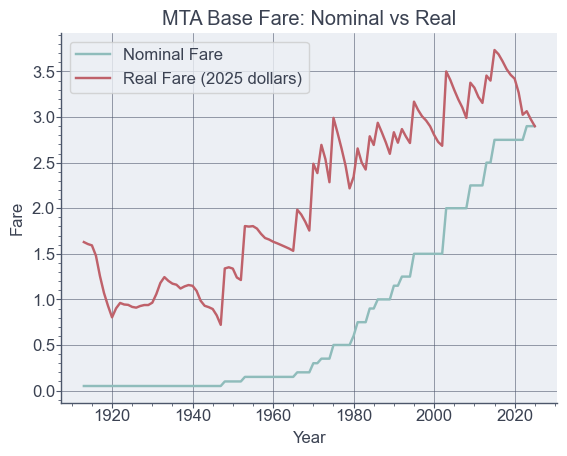

In [32]:
plt.figure()

plt.plot(df["year"], df["base_fare"], label="Nominal Fare")

plt.plot(df["year"], df["base_fare_real_2025"], label="Real Fare (2025 dollars)")

plt.title("MTA Base Fare: Nominal vs Real")

plt.xlabel("Year")

plt.ylabel("Fare")

plt.legend()

plt.show()

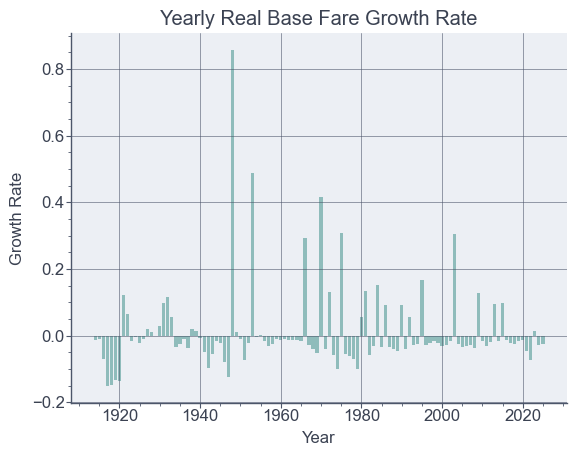

In [33]:
df["fare_growth"] = df["base_fare_real_2025"].pct_change()

plt.figure()

plt.bar(df["year"], df["fare_growth"])

plt.title("Yearly Real Base Fare Growth Rate")

plt.xlabel("Year")

plt.ylabel("Growth Rate")

plt.show()

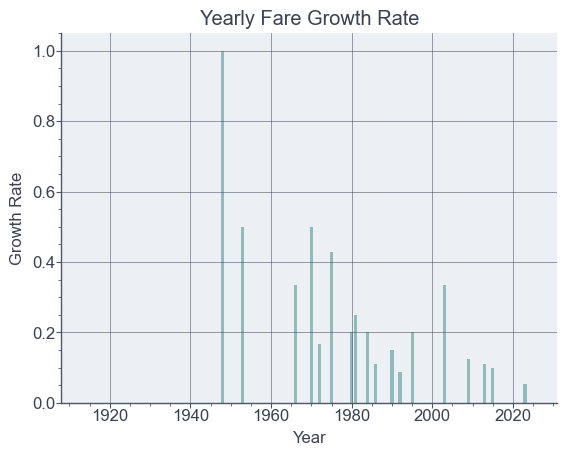

In [34]:
df["fare_growth"] = df["base_fare"].pct_change()

plt.figure()

plt.bar(df["year"], df["fare_growth"])

plt.title("Yearly Fare Growth Rate")

plt.xlabel("Year")

plt.ylabel("Growth Rate")

plt.show()

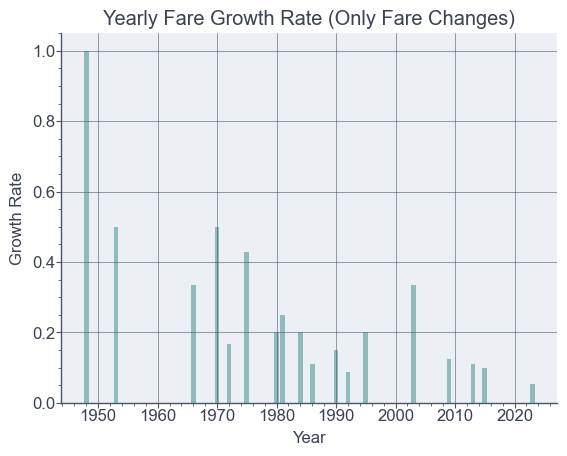

In [35]:
df["fare_growth"] = df["base_fare"].pct_change()

growth_years = df[df["fare_growth"] != 0]

plt.figure()

plt.bar(growth_years["year"], growth_years["fare_growth"])

plt.title("Yearly Fare Growth Rate (Only Fare Changes)")

plt.xlabel("Year")

plt.ylabel("Growth Rate")

plt.show()

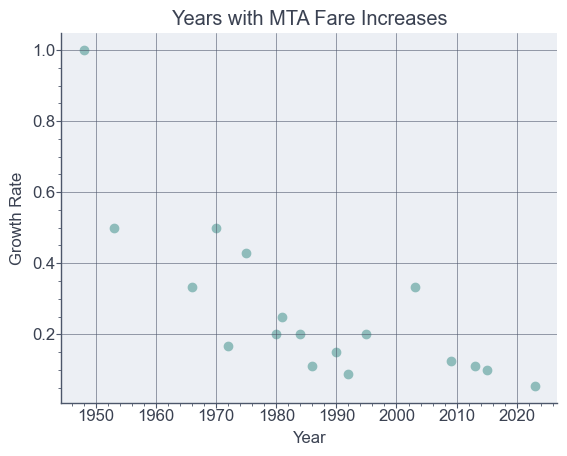

In [36]:
plt.figure()

plt.scatter(growth_years["year"], growth_years["fare_growth"])

plt.title("Years with MTA Fare Increases")

plt.xlabel("Year")

plt.ylabel("Growth Rate")

plt.show()

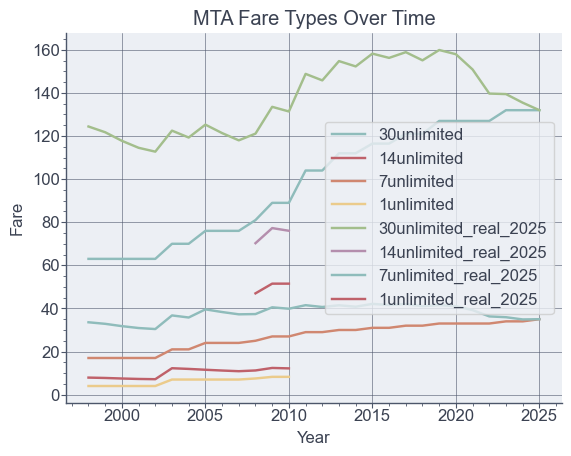

In [37]:
plt.figure()

for col in ["30unlimited","14unlimited","7unlimited","1unlimited", 
            "30unlimited_real_2025", "14unlimited_real_2025", "7unlimited_real_2025", "1unlimited_real_2025"]:
    plt.plot(df["year"], df[col], label=col)

plt.title("MTA Fare Types Over Time")

plt.xlabel("Year")

plt.ylabel("Fare")

plt.legend()

plt.show()